# Estimación del parametro Theta (elasticidad del comercio)

In [14]:
# imports:

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import os, unicodedata, re
import matplotlib.pyplot as plt

In [ ]:
# Paths: 
BASE_DATA   = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data'
BASE_DIST   = BASE_DATA + '/distancia'
BASE_POB    = BASE_DATA + '/población'
OUT_DIR = BASE_DATA + '/resultados_pipeline/'

SPELLING_ALIASES = {
    'AYSEN': 'AISEN', 'COYHAIQUE': 'COIHAIQUE',
    'TREHUACO': 'TREGUACO', 'PAIHUANO': 'PAIGUANO',
    'MARCHIGUE': 'MARCHIHUE',
    'CHIGUAYANTE': 'CONCEPCION', 'SAN PEDRO DE LA PAZ': 'CONCEPCION',
    'HUALPEN': 'TALCAHUANO', 'PADRE LAS CASAS': 'TEMUCO',
    'ALTO HOSPICIO': 'IQUIQUE'
}

# Corrección nombres de comunas.
def normalizar(txt):
    if pd.isna(txt): return ''
    txt = str(txt).strip().upper()
    txt = unicodedata.normalize('NFD', txt)
    txt = ''.join(c for c in txt if unicodedata.category(c) != 'Mn')
    txt = re.sub(r'[^A-Z ]', '', txt)
    return SPELLING_ALIASES.get(txt, txt)

In [ ]:
# Bases: 
print("Cargando bases...")
# data electoral 
df_elec = pd.read_csv(OUT_DIR + 'base_electoral_completa_todos_iv.csv')
df_elec['log_pob_1970'] = np.log(df_elec['pob_1970'].replace(0, np.nan))
df_elec['region_cat'] = df_elec['region'].astype(str)

# mapping histórico: clasificaciones hija y madre. 
df_map = pd.read_csv('/Users/Angelo/Dropbox/Tesis 2026 ME/Codes/mapping_1970_2024.csv')
df_map['h_norm'] = df_map['daughter_2024'].apply(normalizar)
df_map['m_norm'] = df_map['mother_1970'].apply(normalizar)
hija_a_madre = pd.Series(df_map.m_norm.values, index=df_map.h_norm.values).to_dict()


# data población madre e hija. 
df_pob = pd.read_excel(BASE_POB + '/Consolidado informacion censos historicos .xlsx')
df_pob['norm'] = df_pob['Nombre Comuna'].apply(normalizar)
df_pob['madre'] = df_pob['norm'].apply(lambda x: hija_a_madre.get(x, x))
df_pob['p1970'] = pd.to_numeric(df_pob['1970'], errors='coerce').fillna(0)
pop_madre = df_pob.groupby('madre')['p1970'].sum().to_dict()
comunas_con_pob = set(c for c, p in pop_madre.items() if p > 0)

Cargando bases...


In [ ]:

#  Procesamiento de matrices OD con mapping histórico: nos quedamos con el menor tiempo entre cada par-destino sobre las comunas hijas.
def ajustar_od_comunas1970(df_od):
    df = df_od.copy()
    df['o_norm'] = df['origin_COMUNA'].apply(normalizar)
    df['d_norm'] = df['destination_COMUNA'].apply(normalizar)
    df['o_madre'] = df['o_norm'].apply(lambda x: hija_a_madre.get(x, x))
    df['d_madre'] = df['d_norm'].apply(lambda x: hija_a_madre.get(x, x))
    df_agg = df.groupby(['o_madre', 'd_madre'])['time_min'].min().reset_index()
    df_agg.columns = ['origin_COMUNA', 'destination_COMUNA', 'time_min']
    return df_agg

od_1970 = ajustar_od_comunas1970(pd.read_csv(BASE_DIST + '/matriz_OD_1970.csv'))
od_1980 = ajustar_od_comunas1970(pd.read_csv(BASE_DIST + '/matriz_OD_1980.csv'))


od_1970 = od_1970[(od_1970['origin_COMUNA'] != od_1970['destination_COMUNA']) &
                  (od_1970['time_min'] > 0) & (od_1970['time_min'] < float('inf')) &
                  (od_1970['origin_COMUNA'].isin(comunas_con_pob))]
od_1980 = od_1980[(od_1980['origin_COMUNA'] != od_1980['destination_COMUNA']) &
                  (od_1980['time_min'] > 0) & (od_1980['time_min'] < float('inf')) &
                  (od_1980['origin_COMUNA'].isin(comunas_con_pob))]

od_1970['pop_dest'] = od_1970['destination_COMUNA'].map(pop_madre).fillna(0)
od_1980['pop_dest'] = od_1980['destination_COMUNA'].map(pop_madre).fillna(0)


# Función delta market access para un dado theta. 
def calc_delta_ma(theta):
    od70 = od_1970.copy()
    od80 = od_1980.copy()
    od70['MA_term'] = od70['pop_dest'] * (od70['time_min'] ** (-theta))
    od80['MA_term'] = od80['pop_dest'] * (od80['time_min'] ** (-theta))
    
    ma70 = od70.groupby('origin_COMUNA')['MA_term'].sum()
    ma80 = od80.groupby('origin_COMUNA')['MA_term'].sum()
    
    delta = (np.log(ma80) - np.log(ma70)).reset_index()
    delta.columns = ['comuna', 'delta_ma']
    return delta

# Rango de valores para theta 
thetas = np.arange(0.5, 20.1, 0.5)
results = []
# Dependiente política principal.
dep = 'share_si_88'

# Inicialización de calculo por mínimos cuadrados no líneales, tomando como especificación una relación con controles de ruralidad, población 
# 1970 y efecto fijo región. Dependiente corresponde a porcentaje de votos hacia el Sí. 
for th in thetas:
    delta_df = calc_delta_ma(th)
    df_reg = df_elec.merge(delta_df, on='comuna', how='inner')
    df_clean = df_reg.dropna(subset=[dep, 'delta_ma', 'share_rural_1992', 'log_pob_1970', 'region_cat'])
    
    formula = f"{dep} ~ delta_ma + share_rural_1992 + log_pob_1970 + C(region_cat)"
    try:
        model = smf.ols(formula, data=df_clean).fit()
        ssr = model.ssr
        results.append({'theta': th, 'SSR': ssr, 'R2_adj': model.rsquared_adj, 
                        'Coef': model.params.get('delta_ma', np.nan), 'p_valor': model.pvalues.get('delta_ma', np.nan)})
    except: pass


# Resultados: Se toma el theta que minimiza el error cuadrático del setting empírico. 
res_df = pd.DataFrame(results)
best_theta = res_df.loc[res_df['SSR'].idxmin()]
print(f"\nTheta óptimo encontrado: {best_theta['theta']:.2f}")
print(f"SSR mínimo: {best_theta['SSR']:.4f}")
print(f"Coeficiente MA: {best_theta['Coef']:.4f} (p={best_theta['p_valor']:.3f})")

Iniciando Grid Search NLS para Theta...

Theta óptimo encontrado: 4.00
SSR mínimo: 1.6378
Coeficiente MA: -0.0208 (p=0.012)


Cargando bases...
Iniciando Grid Search NLS para Theta...

Theta óptimo encontrado: 4.00
SSR mínimo: 1.6378
Coeficiente MA: -0.0208 (p=0.012)
Guardado en /Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/resultados_pipeline/nls_theta_profile.png


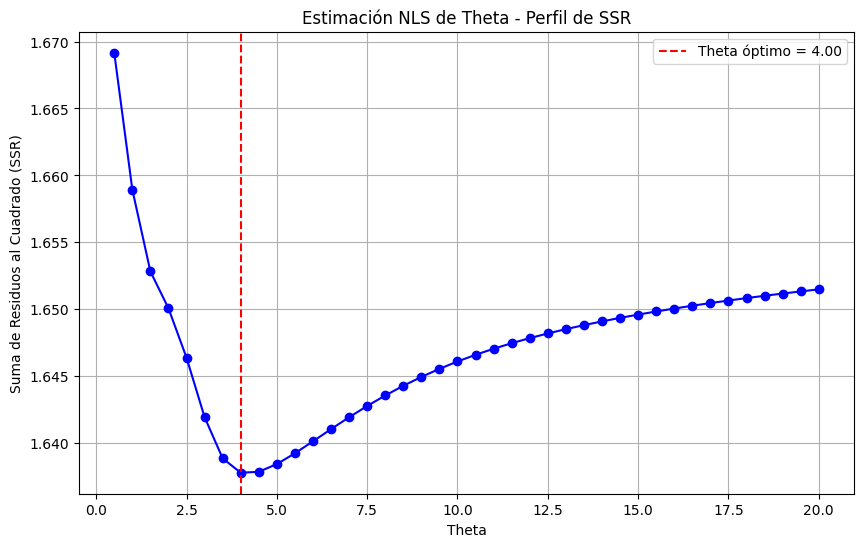

In [ ]:
# Curva suma de los residuos.
res_df.to_csv(OUT_DIR + 'nls_theta_grid_search.csv', index=False)
plt.figure(figsize=(10, 6))
plt.plot(res_df['theta'], res_df['SSR'], marker='o', color='b')
plt.axvline(best_theta['theta'], color='red', linestyle='--', label=f'Theta óptimo = {best_theta["theta"]:.2f}')
plt.xlabel('Theta')
plt.ylabel('Suma de Residuos al Cuadrado (SSR)')
plt.title('Estimación NLS de Theta - Perfil de SSR')
plt.legend()
plt.grid(True)
plt.savefig(OUT_DIR + 'nls_theta_profile.png')
print(f"Guardado en {OUT_DIR}nls_theta_profile.png")
